# Chaining a cavity into a module (eigenmode + wakefield)

Real machines rarely hold one cavity — they hold a **module** of the same cavity
repeated several times. Pass `chain=N` to any cavity and its geometry is repeated `N`
times end-to-end into **one connected structure**, with an aperture only at each module
end. The argument lives on the geometry, so the *same* `chain` drives **every** analysis
— eigenmode, wakefield, multipacting.

The cavities couple through the beam-pipe **drift** between them, and that drift is a
design knob: `spacing` sets it directly. It can be bundled into `chain`,
`chain={'count': N, 'spacing': gap}`, or passed as its own keyword. Below,
one base cavity is chained into a 4-cavity module and run through **eigenmode** (the
fundamental splitting into a passband) and **wakefield**.

In [1]:
import os
import tempfile

import numpy as np
import matplotlib.pyplot as plt

from cavsim2d import EllipticalCavity
from cavsim2d.utils.style import apply_style

apply_style()
WORK = tempfile.mkdtemp()

CELL = [42, 42, 12, 19, 35, 57.7, 103.3]      # A, B, a, b, Ri, L, Req [mm]
CHAIN = 4                                      # cavities in the module
GAP = 30                                       # inter-cavity drift [mm]

single = EllipticalCavity(1, CELL, CELL, CELL, beampipe='both', name='single')
# `chain` bundles the copy count and the inter-cavity drift in one argument
module = EllipticalCavity(1, CELL, CELL, CELL, beampipe='both',
                          chain={'count': CHAIN, 'spacing': GAP}, name='module')
for cav in (single, module):
    cav.set_workspace(os.path.join(WORK, cav.name))
print('module.chain =', module.chain, '| spacing =', module.spacing, 'mm')

module.chain = 4 | spacing = 30 mm


## The geometry

`plot('geometry')` draws the whole module: four cavities, each with its own beam pipes,
joined by the 30 mm inter-cavity drifts into one connected structure with an aperture
only at each end.

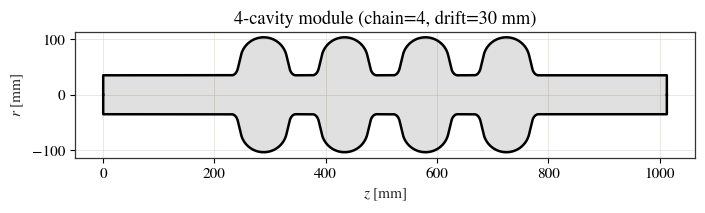

In [2]:
ax = module.plot('geometry', mirror=True, show=False)
ax.set_title('%d-cavity module (chain=%d, drift=%d mm)' % (CHAIN, CHAIN, GAP))
plt.show()

## Eigenmode: the fundamental becomes a passband

A single cavity has one accelerating (TM$_{010}$-like) mode. Chain `N` of them and,
because neighbours couple through the drift, that mode splits into a **passband of `N`
coupled modes** — one per cavity. Solve the module and pick out the monopole passband.

single cavity fundamental : 1288.145 MHz
module passband [MHz]     : [1286.739, 1287.615, 1288.702, 1289.586]


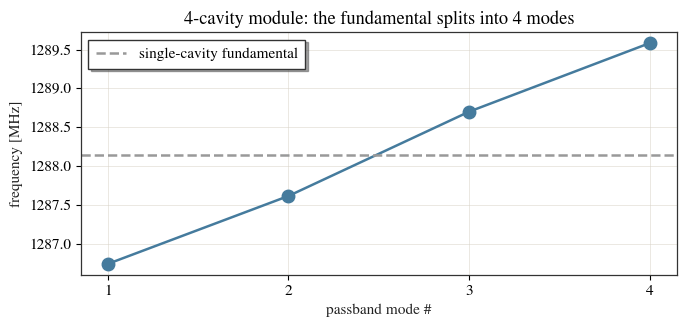

In [3]:
single.eigenmode.run(mesh_config={'h': 12, 'p': 2}, n_modes=1)
f1 = single.eigenmode.qois['freq [MHz]']

module.eigenmode.run(mesh_config={'h': 12, 'p': 2}, n_modes=CHAIN + 2)
fmod = sorted(module.eigenmode.qois_df.query('m == 0')['freq [MHz]'])
passband = [f for f in fmod if f < 1.3 * f1][:CHAIN]      # the fundamental passband

print('single cavity fundamental : %.3f MHz' % f1)
print('module passband [MHz]     :', [round(f, 3) for f in passband])

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(range(1, len(passband) + 1), passband, 'o-', ms=9)
ax.axhline(f1, ls='--', color='0.6', label='single-cavity fundamental')
ax.set_xlabel('passband mode #'); ax.set_ylabel('frequency [MHz]')
ax.set_title('%d-cavity module: the fundamental splits into %d modes' % (CHAIN, len(passband)))
ax.set_xticks(range(1, len(passband) + 1)); ax.legend()
plt.tight_layout(); plt.show()

## Tuning the inter-cavity drift

The drift length is a design knob. `spacing` sets the gap between cavities
directly — a single value for every gap, or a **list of `chain - 1` values** to set each
gap independently (handy for optimisation). Because the coupling falls off with the
drift, the passband **width** is a direct — and optimisable — function of it. Here the
same module is rebuilt at three drift lengths.

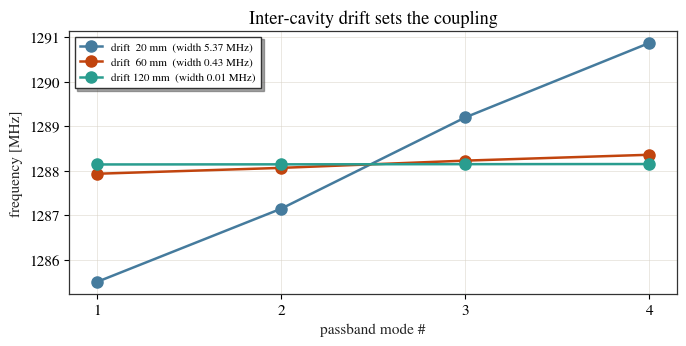

drift  20 mm -> passband width 5.371 MHz
drift  60 mm -> passband width 0.427 MHz
drift 120 mm -> passband width 0.010 MHz


In [4]:
def passband_of(gap_mm):
    m = EllipticalCavity(1, CELL, CELL, CELL, beampipe='both',
                         chain={'count': CHAIN, 'spacing': gap_mm},
                         name='gap%g' % gap_mm)
    m.set_workspace(os.path.join(WORK, m.name))
    m.eigenmode.run(mesh_config={'h': 12, 'p': 2}, n_modes=CHAIN + 2)
    f = sorted(m.eigenmode.qois_df.query('m == 0')['freq [MHz]'])
    return [x for x in f if x < 1.3 * f1][:CHAIN]

drifts = [20, 60, 120]                        # inter-cavity drift lengths [mm]
bands = {g: passband_of(g) for g in drifts}

fig, ax = plt.subplots(figsize=(7, 3.6))
for g in drifts:
    b = bands[g]
    ax.plot(range(1, len(b) + 1), b, 'o-', ms=8,
            label='drift %3d mm  (width %.2f MHz)' % (g, b[-1] - b[0]))
ax.set_xlabel('passband mode #'); ax.set_ylabel('frequency [MHz]')
ax.set_title('Inter-cavity drift sets the coupling')
ax.set_xticks(range(1, CHAIN + 1)); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

for g in drifts:
    print('drift %3d mm -> passband width %.3f MHz' % (g, bands[g][-1] - bands[g][0]))

## Wakefield on the module

Wakefield uses the **same** chained geometry (its ABCI deck is written from the module's
profile), so no extra work is needed — just run it. The beam sees the full module: every
cavity and every drift.

module |k_loss| = 0.7160 V/pC


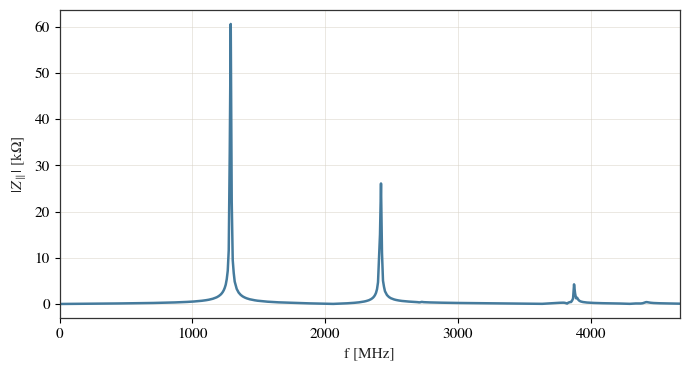

<Axes: xlabel='f [MHz]', ylabel='$|Z_\\parallel|$ [k$\\Omega$]'>

In [5]:
module.wakefield.run({'MROT': 0, 'wakelength': 20, 'bunch_length': 25})
print('module |k_loss| = %.4f V/pC' % module.wakefield.qois['|k_loss| [V/pC]'])
module.wakefield.plot_impedance(kind='longitudinal')

## Reading it

- **`chain=N`** turns any cavity into an `N`-cavity module in one argument — the geometry
  is repeated end-to-end into one connected structure with an aperture at each module end.
- **`spacing`** makes the drift between cavities an explicit knob: bundle it in
  `chain={'count': N, 'spacing': gap}` (or pass it as its own keyword), a single
  value for every gap or a list of `chain - 1` values for each gap.
- **Eigenmode** shows the physics: the single-cavity fundamental splits into a passband of
  `N` coupled modes, and the passband **width** tracks the drift — a shorter drift couples
  the cavities more strongly. It is a real, optimisable parameter.
- **Wakefield** (and multipacting) use the same chained geometry automatically — the
  argument lives on the cavity, so every analysis sees the module.
